In [165]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import glob
import pandas as pd
import datetime
import numpy as np
import polars as pl
from pathlib import Path
from datetime import timedelta
from datetime import datetime
import missingno as msno


# DATA2
주제 2. 구독서비스 프로덕트 데이터 분석

| #  | 컬럼명              | 컬럼 설명                                                     | 컬럼 타입  | 비고                                                                                                                                   |
|:--:|:-------------------|:-------------------------------------------------------------|:---------|:---------------------------------------------------------------------------------------------------------------------------------------|
| 1  | **city**           | 접속 위치                                                    | Object   | 국내 기준 “시” 단위로 제공하나, 서울의 경우 “구”가 특정되는 경우는 “구” 단위로 표기                                                |
| 2  | **client_event_time** | 타임스탬프 (UTC+0 기준)                                   | Object   | -                                                                                                                                     |
| 3  | **country**        | 접속 국가                                                    | Object   | -                                                                                                                                     |
| 4  | **device_carrier** | 사용 이동통신사                                             | float64  | -                                                                                                                                     |
| 5  | **device_family**  | 사용 기기 유형                                              | Object   | -                                                                                                                                     |
| 6  | **device_type**    | 사용 기기                                                   | Object   | -                                                                                                                                     |
| 7  | **event_type**     | 이벤트 유형                                                 | Object   | 테이블명과 동일                                                                                                                       |
| 8  | **language**       | 사용자 설정 언어                                            | Object   | -                                                                                                                                     |
| 9  | **os_name**        | 사용 브라우저 이름                                          | Object   | -                                                                                                                                     |
| 10 | **os_version**     | 사용 브라우저 버전                                          | Object   | -                                                                                                                                     |
| 11 | **platform**       | 사용 플랫폼                                                | Object   | -                                                                                                                                     |
| 12 | **user_id**        | 유저 id                                                    | Object   | -                                                                                                                                     |

앰플리튜드 로그, GA로그와 유사한 형태

In [166]:
#디렉토리 경로
DATA_DIR = Path(r"C:\Users\user\Desktop\playground\codeit_DA_13th\projects\intermediate1\midproject1\DBsources\topic2")

### 국가 비중 분포 확인 + 한국 데이터만 필터링

In [167]:
# 범용 국가 비중 분포 확인 + 한국(South Korea) 데이터만 필터링 후 전처리 적용

def preprocess_korea_data(file_name: str) -> pl.DataFrame:
    """
    Parquet 파일을 불러와 국가 분포를 확인하고, 
    한국 데이터 필터링 및 공통 전처리를 수행하는 함수
    """
    print(f"🚀 [{file_name}] 데이터 로드 및 전처리 시작...")
    
    # 1. 데이터 로드
    df = pl.read_parquet(DATA_DIR / file_name)
    
    # 2. 국가별 데이터 분포 확인 및 한국 데이터 필터링
    if "country" in df.columns:
        country_dist = (
            df
            .group_by("country")
            .agg(pl.len().alias("count_star()"))
            .sort("count_star()", descending=True)
        )
        print("=== 국가별 데이터 분포 (Top 10) ===")
        print(country_dist.head(10))
        
        # 한국 데이터만 추출
        df = df.filter(pl.col("country") == "South Korea")
    else:
        print("⚠️ 'country' 컬럼이 없어 국가 필터링을 건너뜁니다.")

    # 3. 공통 전처리 로직 (결측치 표준화 및 시간대 변환)
    preprocess_exprs = [
        # 문자열 컬럼 결측치 표준화
        pl.col(pl.Utf8).replace(["", "nan", "NaN"], None)
    ]
    
    # client_event_time 컬럼이 존재하는 경우에만 시간 변환 적용
    if "client_event_time" in df.columns:
        preprocess_exprs.append(
            pl.col("client_event_time") + timedelta(hours=9)
        )
        
    df = df.with_columns(preprocess_exprs)
    
    # 4. 결과 요약 출력
    print(f"=== 전처리 완료: {file_name} (한국 데이터) ===")
    print(f"총 데이터 수: {df.height}행")
    print("-" * 50)
    
    return df

### 시간 범위 확인 + 요약 통계 출력

In [168]:
# 시간 범위 확인 + 요약 통계 출력

def profile_dataframe(df: pl.DataFrame, table_name: str = "DataFrame") -> pl.DataFrame:
    """
    데이터프레임의 시간 범위 및 컬럼별 요약 통계(결측치, 유니크, 최빈값)를 확인하는 함수
    """
    pl.Config.set_tbl_rows(30)  # 모든 행 표시
    pl.Config.set_tbl_cols(-1)  # 모든 컬럼 표시
    pl.Config.set_fmt_str_lengths(50) # 문자열 생략 방지 (필요시 조절)

    print(f"\n📊 === [{table_name}] EDA 프로파일링 ===")
    print(f"총 데이터 수(shape): ({df.height}, {df.width})\n")

    # 1. 시간 범위 확인 블록
    if "client_event_time" in df.columns:
        time_summary = df.select([
            pl.col("client_event_time").min().alias("min_time"),
            pl.col("client_event_time").max().alias("max_time")
        ])
        print("=== 시간 범위 ===")
        print(time_summary)
        print("\n")

    # 2. 컬럼별 요약 통계 산출 블록
    total_rows = df.height
    
    # 데이터가 비어있지 않은 경우에만 실행
    if total_rows > 0:
        # 각 통계량을 병렬로 계산한 뒤 unpivot(구 melt)으로 세로 변환
        null_counts = df.select(
            pl.all().null_count()
        ).unpivot(variable_name="column", value_name="null_count")

        unique_counts = df.select(
            pl.all().n_unique()
        ).unpivot(variable_name="column", value_name="n_unique")

        # 최빈값은 타입 충돌을 막기 위해 String으로 캐스팅
        modes = df.select(
            pl.all().drop_nulls().mode().first().cast(pl.String)
        ).unpivot(variable_name="column", value_name="mode")

        # 3개의 요약 데이터를 조인하고 결측치 비율(%) 계산
        summary_df = (
            null_counts
            .join(unique_counts, on="column")
            .join(modes, on="column")
            .with_columns(
                (pl.col("null_count") / total_rows * 100).round(2).alias("null_pct(%)")
            )
            .select(["column", "null_count", "null_pct(%)", "n_unique", "mode"]) # 출력 순서 정렬
        )

        print("=== 컬럼별 요약 통계 ===")
        print(summary_df)
        
        return summary_df
    else:
        print("⚠️ 데이터프레임이 비어 있습니다 (0행).")
        return pl.DataFrame()

# enter.main_page
- 서비스 메인페이지 진입

In [169]:
enter_main_page_kr = preprocess_korea_data('enter_main_page.parquet')

🚀 [enter_main_page.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬──────────────┐
│ country        ┆ count_star() │
│ ---            ┆ ---          │
│ str            ┆ u32          │
╞════════════════╪══════════════╡
│ South Korea    ┆ 2079303      │
│ United States  ┆ 18925        │
│ Japan          ┆ 5329         │
│ Canada         ┆ 4142         │
│ Germany        ┆ 3009         │
│ Ireland        ┆ 2144         │
│ Australia      ┆ 1970         │
│                ┆ 1869         │
│ Singapore      ┆ 1736         │
│ United Kingdom ┆ 1688         │
└────────────────┴──────────────┘
=== 전처리 완료: enter_main_page.parquet (한국 데이터) ===
총 데이터 수: 2079303행
--------------------------------------------------


In [170]:
enter_main_page_kr_summary = profile_dataframe(enter_main_page_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (2079303, 12)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-05-10 15:16:36 ┆ 2023-12-15 11:46:11 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (12, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 44495      ┆ 2.14        ┆ 491      ┆ Seoul           

- 최소시간이 1978년도?
- 모두 웹 / 이벤트 타입 동일
- 이동통신사 결측치 100%
- 유저id 결측치가 75%이다. 이는 로그인 정보가 없는 상태인 유저들이라고 판단해야할 듯 / 비로그인상태
- 국적이 172개나 된다..?

In [171]:
# (선택) 추가 전처리 작업
import polars as pl

# 앞서 생성한 enter_main_page_kr (한국 트래픽 필터링 완료) 데이터프레임에 적용합니다.

enter_main_page_kr_clean = (
    enter_main_page_kr
    # 1. 이상치 제거: 1978년 등 비정상적인 과거 로그 제외 (예: 2020년 1월 1일 이후 정상 로그만 유지)
    .filter(pl.col("client_event_time") >= datetime(2020, 1, 1))
    
    # 2. 파생 변수 생성: user_id의 존재 여부에 따라 로그인 상태(is_logged_in) boolean 컬럼 추가
    .with_columns([
        pl.col("user_id").is_not_null().alias("is_logged_in")
    ])
    
    # 3. 불필요한 컬럼 제거 (메모리 최적화 및 노이즈 제거)
    # - device_carrier: 100% 결측치
    # - country: 모두 'South Korea'이므로 변별력 없음
    # - platform: 모두 'Web'이므로 변별력 없음
    # - event_type: 모두 'enter.main_page'이므로 변별력 없음
    .drop(["device_carrier", "country", "platform", "event_type"])
)

# 정제 결과 확인
print("=== 정제 완료: enter_main_page_clean ===")
print(f"정제 전: {enter_main_page_kr.height}행 -> 정제 후: {enter_main_page_kr_clean.height}행")
print(enter_main_page_kr_clean.head())

=== 정제 완료: enter_main_page_clean ===
정제 전: 2079303행 -> 정제 후: 2079303행
shape: (5, 9)
┌───────────┬──────────┬──────────┬──────────┬──────────┬─────────┬──────────┬──────────┬──────────┐
│ city      ┆ client_e ┆ device_f ┆ device_t ┆ language ┆ os_name ┆ os_versi ┆ user_id  ┆ is_logge │
│ ---       ┆ vent_tim ┆ amily    ┆ ype      ┆ ---      ┆ ---     ┆ on       ┆ ---      ┆ d_in     │
│ str       ┆ e        ┆ ---      ┆ ---      ┆ str      ┆ str     ┆ ---      ┆ str      ┆ ---      │
│           ┆ ---      ┆ str      ┆ str      ┆          ┆         ┆ str      ┆          ┆ bool     │
│           ┆ datetime ┆          ┆          ┆          ┆         ┆          ┆          ┆          │
│           ┆ [μs]     ┆          ┆          ┆          ┆         ┆          ┆          ┆          │
╞═══════════╪══════════╪══════════╪══════════╪══════════╪═════════╪══════════╪══════════╪══════════╡
│ Seongnam- ┆ 2023-04- ┆ Samsung  ┆ Samsung  ┆ Korean   ┆ Whale   ┆ 1.0.0.0  ┆ null     ┆ false    │
│ si   

# enter.signup_page
- 회원가입 페이지 진입

In [172]:
enter_signup_page_kr = preprocess_korea_data('enter_signup_page.parquet')

🚀 [enter_signup_page.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌───────────────┬──────────────┐
│ country       ┆ count_star() │
│ ---           ┆ ---          │
│ str           ┆ u32          │
╞═══════════════╪══════════════╡
│ South Korea   ┆ 580618       │
│ United States ┆ 2848         │
│ India         ┆ 2656         │
│ Japan         ┆ 1276         │
│ Canada        ┆ 796          │
│ Germany       ┆ 607          │
│ Australia     ┆ 555          │
│ Egypt         ┆ 533          │
│ Bangladesh    ┆ 522          │
│               ┆ 514          │
└───────────────┴──────────────┘
=== 전처리 완료: enter_signup_page.parquet (한국 데이터) ===
총 데이터 수: 580618행
--------------------------------------------------


In [224]:
enter_signup_page_kr_summary = profile_dataframe(enter_signup_page_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (580618, 12)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-11-25 09:08:18 ┆ 2024-01-01 08:59:22 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (12, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                       │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                        │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                        │
╞═══════════════════╪════════════╪═════════════╪══════════╪════════════════════════════╡
│ city              ┆ 13248      ┆ 2.28        ┆ 435      ┆ Seoul                      │
│ client_event_tim

- 이동 통신사는 결측치항상 0 인듯
- user_id 모두 nan이다. 회원가입 후 user_id 부여되는 듯
- 도시와 국가 최빈값을 보니 국내 위주의 서비스로 추측
- 회원가입페이지 진입 후 회원가입 완료 유저에 대해 퍼널 연결이 가능할지? -> complete.sighup과 시간대별 비교하는 수 밖에 없다. 데이터 조인은 불가     

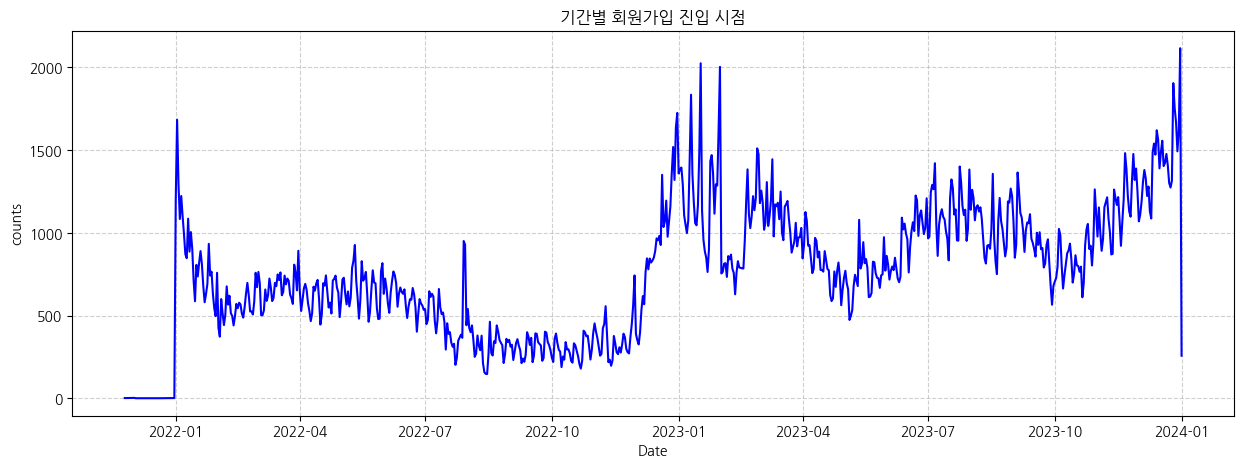

In [174]:
# 한글 폰트 설정 (환경에 맞게 주석 해제하여 사용)
# plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. Polars를 활용한 날짜별 집계 (Pandas의 value_counts().sort_index() 대체)
daily_signup_enters = (
    enter_signup_page_kr
    # client_event_time에서 날짜(Date)만 추출하여 새로운 컬럼 생성
    .with_columns(pl.col("client_event_time").dt.date().alias("event_date"))
    # 날짜별 그룹화 및 데이터 개수 카운트
    .group_by("event_date")
    .agg(pl.len().alias("counts"))
    # 시간 순서대로 정렬
    .sort("event_date")
)

# 2. Matplotlib 시각화
plt.figure(figsize=(15, 5))
# Polars Series를 그대로 plt.plot에 전달 가능
plt.plot(
    daily_signup_enters["event_date"], 
    daily_signup_enters["counts"], 
    linestyle='-', 
    color='b'
)
plt.title('기간별 회원가입 진입 시점')
plt.ylabel('counts')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.6) # 추세를 보기 쉽게 그리드 추가
plt.show()

- 주말과 주중의 주기가 존재하는듯?
- 피크치는 기간에는 특정 프로모션을 했던것이 아닌가 추측 해볼 수 있음

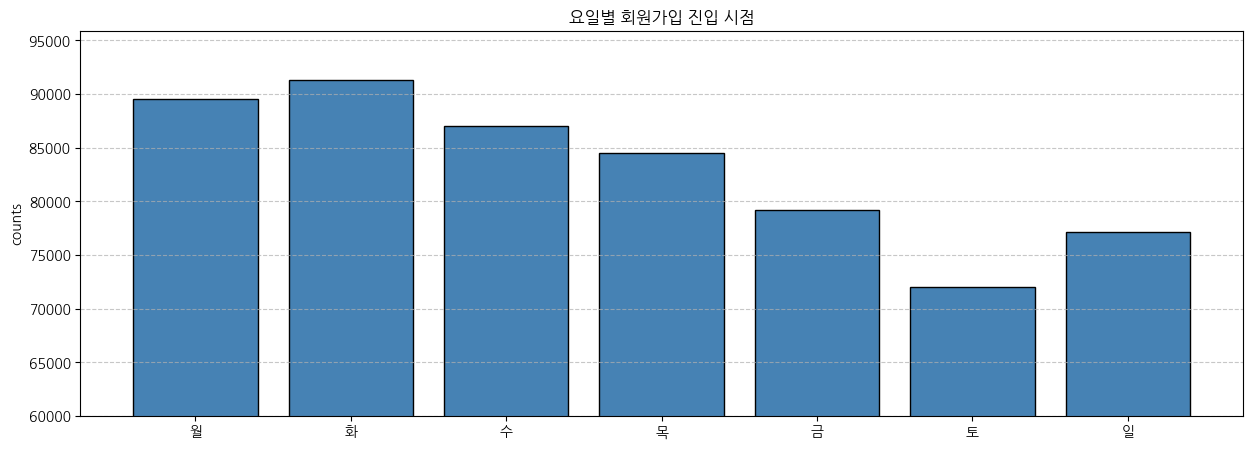

In [175]:
# 1. Polars를 활용한 요일별 집계
# 주의: Polars의 dt.weekday()는 1(월) ~ 7(일)을 반환합니다.
weekday_signup = (
    enter_signup_page_kr
    .with_columns(pl.col("client_event_time").dt.weekday().alias("weekday"))
    .group_by("weekday")
    .agg(pl.len().alias("counts"))
    .sort("weekday")
)

# 2. Matplotlib 시각화 (Bar chart)
plt.figure(figsize=(15, 5))

# X축 라벨을 숫자가 아닌 직관적인 요일명으로 변경 (선택 사항)
weekday_names = ['월', '화', '수', '목', '금', '토', '일']
x_labels = [weekday_names[i-1] for i in weekday_signup["weekday"]]

# 막대그래프 그리기
plt.bar(x_labels, weekday_signup["counts"], color='steelblue', edgecolor='black')

# y축 하한값 설정 (사용하신 plt.ylim(60000)을 더 명시적으로 작성)
plt.ylim(bottom=60000) 

# 제목은 '기간별' 대신 '요일별'이 더 적합해 보여서 살짝 수정했습니다.
plt.title('요일별 회원가입 진입 시점') 
plt.ylabel('counts')
plt.grid(axis='y', linestyle='--', alpha=0.7) # y축 기준 그리드 추가로 가독성 향상
plt.show()

토요일이 가장 낮은 가입진입
- 국가별로 시차 확인
- web 서비스이기 때문에 모바일 기종으로 가입하는 경우는 낮을 것이라 추측 -> 확인필요
- 데스크탑 vs 모바일의 다양한 기준으로 특성 차이 비교해보기

# complete.signup.csv
- 회원가입 완료

| 테이블명                                                | 테이블 설명                        | 컬럼명             | 타입     | 컬럼 설명                | 비고                                         |
|:--------------------------------------------------------|:-----------------------------------|:-------------------|:---------|:-------------------------|:---------------------------------------------|
|  **complete.signup**                                     | 회원가입 완료                      | type              | object   | 로그인 방식             | -                                           |

In [176]:
complete_signup_kr = preprocess_korea_data('complete_signup.parquet')

🚀 [complete_signup.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌───────────────┬──────────────┐
│ country       ┆ count_star() │
│ ---           ┆ ---          │
│ str           ┆ u32          │
╞═══════════════╪══════════════╡
│               ┆ 99377        │
│ South Korea   ┆ 45306        │
│ United States ┆ 120          │
│ Japan         ┆ 91           │
│ Canada        ┆ 43           │
│ Vietnam       ┆ 23           │
│ Australia     ┆ 12           │
│ Germany       ┆ 11           │
│ Netherlands   ┆ 10           │
│ Hong Kong     ┆ 10           │
└───────────────┴──────────────┘
=== 전처리 완료: complete_signup.parquet (한국 데이터) ===
총 데이터 수: 45306행
--------------------------------------------------


In [177]:
complete_signup_kr_summary = profile_dataframe(complete_signup_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (45306, 13)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-01-01 09:06:31 ┆ 2023-12-28 11:36:11 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (13, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 949        ┆ 2.09        ┆ 295      ┆ Seoul             

68%의 결측치가 일정하게 존재하는 경우들이 있다. 이는 시스템상의 업데이트로 수집 시작한 기간이 달라 발생했을 것이라 유추

<Figure size 1000x300 with 0 Axes>

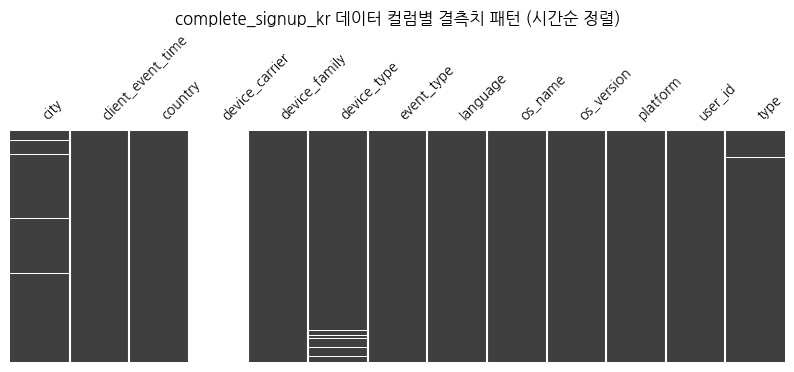

In [178]:
# 한글 폰트 설정 (환경에 맞게 주석 해제하여 사용하세요)
# plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

sorted_signup_pd = (
    complete_signup_kr
    .sort("client_event_time")
    .to_pandas() # missingno 사용을 위해 Pandas 변환 (필수)
)

# 3. missingno 시각화 (Pandas 데이터프레임 사용)
plt.figure(figsize=(10, 3)) # msno 내부 plt와 충돌 방지를 위해 빈 figure 생성

# 스파크라인을 제거하고, 글자 크기 조정
msno.matrix(
    sorted_signup_pd, 
    figsize=(10, 3), # msno 내부에 figsize 다시 명시 
    fontsize=10, 
    sparkline=False
)

# y축 눈금 제거 및 제목 설정 (user 가 요청한 verbatim 유지하되 .csv 만 수정)
plt.title('complete_signup_kr 데이터 컬럼별 결측치 패턴 (시간순 정렬)')
plt.yticks([]) 
plt.show()

- 특정기간대에 결측치가 발생하는 것은 아님
- 결측치가 있는 행은 대체로 같은 컬럼들에서 켤측치를 가진다

In [179]:
type_counts = complete_signup_kr["type"].value_counts(sort=True)
print("=== 회원가입 완료 type 분포 ===")
print(type_counts)

=== 회원가입 완료 type 분포 ===
shape: (6, 2)
┌──────────┬───────┐
│ type     ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ kakao    ┆ 26929 │
│ naver    ┆ 7311  │
│ google   ┆ 6478  │
│ email    ┆ 4371  │
│ facebook ┆ 130   │
│ null     ┆ 87    │
└──────────┴───────┘


가입 경로를 확인해봤을 때, 카카오,네이버가 많다 -> 대한민국 대상 서비스
- 회원가입 시점과 비교해보기
- 국가정보도 확ㅇ니해보기~

In [180]:
type_counts = complete_signup_kr["type"].value_counts(sort=True)
print("=== 회원가입 완료 type 분포 ===")
print(type_counts)

=== 회원가입 완료 type 분포 ===
shape: (6, 2)
┌──────────┬───────┐
│ type     ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ kakao    ┆ 26929 │
│ naver    ┆ 7311  │
│ google   ┆ 6478  │
│ email    ┆ 4371  │
│ facebook ┆ 130   │
│ null     ┆ 87    │
└──────────┴───────┘


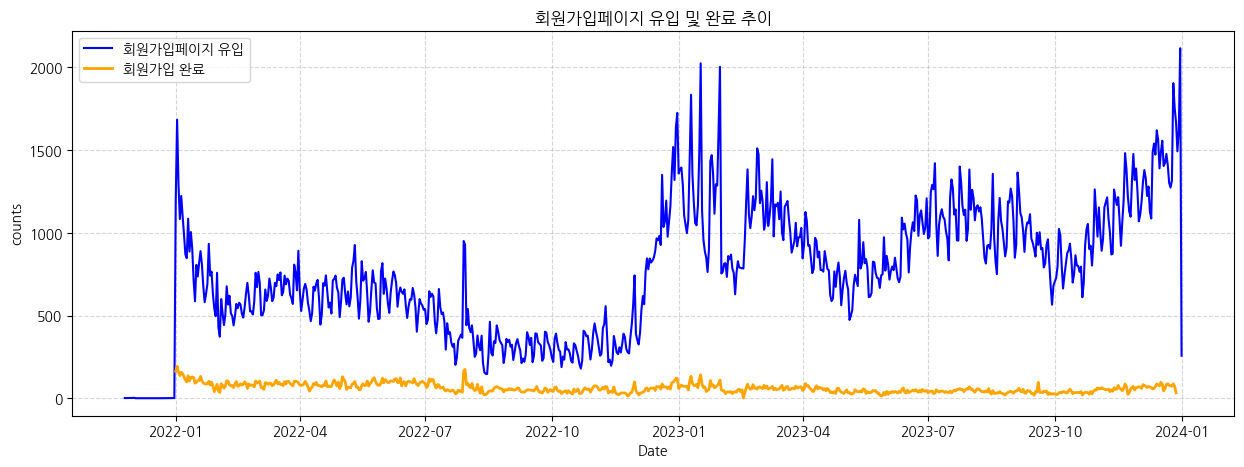

In [181]:
# 1. 회원가입 페이지 진입 일자별 집계
daily_enter = (
    enter_signup_page_kr
    .with_columns(pl.col("client_event_time").dt.date().alias("date"))
    .group_by("date")
    .agg(pl.len().alias("enter_cnt"))
    .sort("date")
)

# 2. 회원가입 완료 일자별 집계
daily_signup = (
    complete_signup_kr
    .with_columns(pl.col("client_event_time").dt.date().alias("date"))
    .group_by("date")
    .agg(pl.len().alias("complete_cnt"))
    .sort("date")
)

# 3. Matplotlib 시각화
plt.figure(figsize=(15, 5))

# 유입 트래픽 라인
plt.plot(
    daily_enter["date"], 
    daily_enter["enter_cnt"], 
    label='회원가입페이지 유입', 
    color='blue'
)

# 완료 트래픽 라인
plt.plot(
    daily_signup["date"], 
    daily_signup["complete_cnt"], 
    label='회원가입 완료', 
    color='orange',
    linewidth=2 # 완료 라인을 조금 더 강조
)

plt.legend()
plt.title('회원가입페이지 유입 및 완료 추이')
plt.xlabel('Date')
plt.ylabel('counts')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

추세는 얼추 비슷해 보인다. 실질적인 비율 상의 차이가 있는지 확인해볼 필요가 있다.
- 유입인원 대비 가입인원을 하나의 지표로 두고 기간별 차이가 있는지 확인해볼만함
- 유입인원은 튀는데 (eg. 23년 11월쯤?) 가입완료는 적은 경우

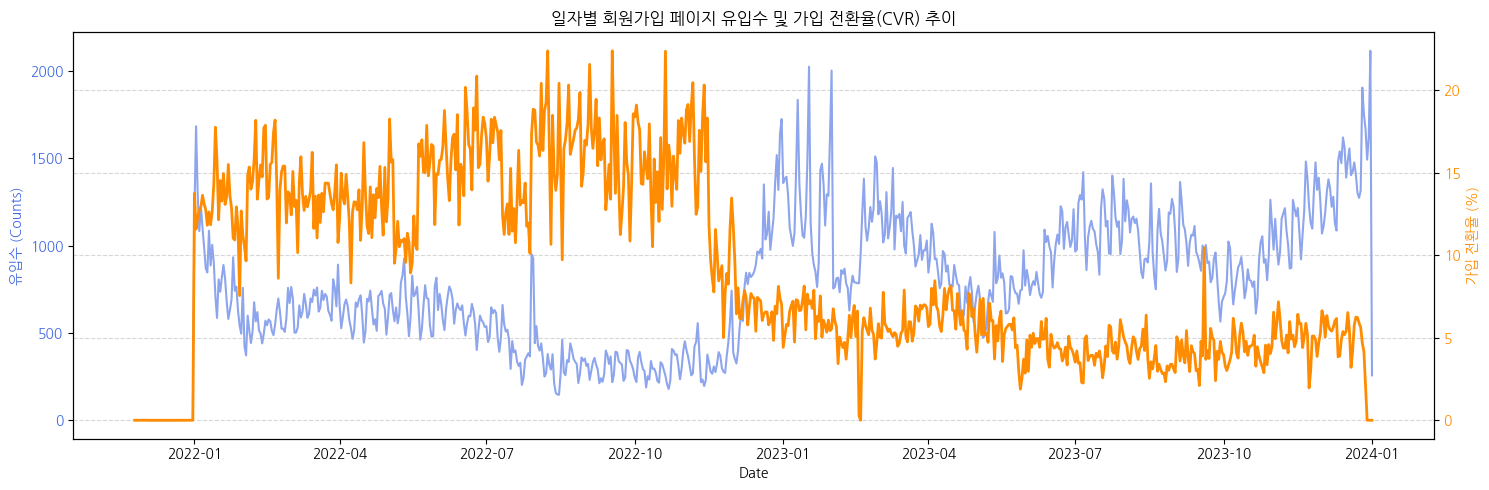

In [182]:
# 데이터 조인 및 전환율(CVR) 계산
cvr_df = (
    daily_enter
    .join(daily_signup, on="date", how="left")
    # 결측치(가입 완료가 0건인 날)를 0으로 채움
    .fill_null(0)
    # 전환율(%) 계산: (완료수 / 유입수) * 100
    .with_columns(
        (pl.col("complete_cnt") / pl.col("enter_cnt") * 100).alias("cvr_pct")
    )
    .sort("date")
    # Pandas 변환 전 데이터 확인용 (선택)
    # .to_pandas() 
)

# --- 시각화 (이중 축 그래프) ---
# Polars DataFrame을 Pandas로 변환하여 Matplotlib에 전달
df_viz = cvr_df.to_pandas()

fig, ax1 = plt.subplots(figsize=(15, 5))

# 첫 번째 축 (왼쪽 Y축): 유입수 (파란색 영역/선)
color1 = 'royalblue'
ax1.set_xlabel('Date')
ax1.set_ylabel('유입수 (Counts)', color=color1)
ax1.plot(df_viz["date"], df_viz["enter_cnt"], color=color1, alpha=0.6, label='페이지 유입')
ax1.tick_params(axis='y', labelcolor=color1)

# 두 번째 축 (오른쪽 Y축): 가입 전환율 (주황색 선)
ax2 = ax1.twinx() 
color2 = 'darkorange'
ax2.set_ylabel('가입 전환율 (%)', color=color2)
ax2.plot(df_viz["date"], df_viz["cvr_pct"], color=color2, linewidth=2, label='전환율(CVR)')
ax2.tick_params(axis='y', labelcolor=color2)

# 그래프 Y축 범위 설정 (전환율이 보통 10~30% 내외라면 상황에 맞게 상한선을 50 등으로 조절)
# ax2.set_ylim(0, 50) 

plt.title('일자별 회원가입 페이지 유입수 및 가입 전환율(CVR) 추이')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [183]:
complete_signup_kr['user_id'].value_counts(sort=True)

user_id,count
str,u32
"""e131c319972bd580146c5a2faba26613""",1
"""e3b8bfa80d866f296aad139e09023ef3""",1
"""43264caf4d797e1c485a8b1f588dc5ce""",1
"""9f9a65b7615301fba1a2b449278d54be""",1
"""e9dd1b9bc5f155f30b20bc19a99bcc93""",1
"""1ecbb1b78ef3e6c5e6451c6e5d14fd45""",1
"""fb2616778e6fe188e51e1bb8e86ede20""",1
"""86017c06e752f3260aaeab93444fc5d5""",1
"""0672f9bd971a7a5a9d6f12fb04032741""",1


모든 User_id는 고유값을 가진다 -> 하나의 id는 1개의 회원 id값을 가짐

# enter.content_page
- 콘텐츠 개별 페이지 진입

| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **enter.content_page**                              | 콘텐츠 개별 페이지 진입                 | content.id         | object | 콘텐츠 id                                       | -    |

In [184]:
enter_content_page_kr = preprocess_korea_data('enter_content_page.parquet')

🚀 [enter_content_page.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬──────────────┐
│ country        ┆ count_star() │
│ ---            ┆ ---          │
│ str            ┆ u32          │
╞════════════════╪══════════════╡
│ South Korea    ┆ 1864218      │
│ United States  ┆ 13912        │
│                ┆ 7570         │
│ Japan          ┆ 6984         │
│ Germany        ┆ 3858         │
│ Canada         ┆ 3504         │
│ Australia      ┆ 1511         │
│ Vietnam        ┆ 1415         │
│ United Kingdom ┆ 1377         │
│ Singapore      ┆ 1030         │
└────────────────┴──────────────┘
=== 전처리 완료: enter_content_page.parquet (한국 데이터) ===
총 데이터 수: 1864218행
--------------------------------------------------


In [185]:
enter_content_page_kr_summary = profile_dataframe(enter_content_page_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (1864218, 13)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-11-04 04:15:12 ┆ 2024-01-01 08:59:19 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (13, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 19690      ┆ 1.06        ┆ 416      ┆ Seoul           

- 유저 결측치가 25% 존재한다. 이를 어떻게 해석해야할지? 회원가입안한 유저가 컨텐츠에 속하게된건가
- 전체행은 191만행이다. 이중 유니크 유저는 7.2만으로 한 유저가 여러 컨텐츠에 포함이 되어 있을 것이다
- 전체 컨텐츠는 208개이다.
    - 컨텐츠는 처음부터 모두 존재했을지? 아니면 특정시기부터 시작되었을지 확인할 필요가 있다.
- 인기있는 컨텐츠는 무엇인지 확인해보기

In [186]:
enter_content_page_kr['user_id'].value_counts(sort=True).head(10)

user_id,count
str,u32
null,454307
"""4f74b6e2f650f4c8db87579e44f5b7d6""",29654
"""d21dc741fde11ffb6768d8bdb3547398""",24270
"""e9261fd1140ae566bddb38c7a4c997cc""",2153
"""2d9b821bb7ad4ae411fc3eab9c0ebfe5""",1991
"""d3b2f51ede04364bd9861f8d261f26ec""",1912
"""57542a51e6d83e2a11fd6f35224067d7""",1874
"""4df798090ee2831f81ea5c60dfa15ad3""",1771
"""681d58f5654892f6d79438751dee2b2d""",1718


상위 2개 유저는 다른 유저 대비해서 상당히 많은 컨텐츠 접근이 있었다.
- 헤비유저 or 개발진 or 내부 공용아이디일 수 있다

In [187]:
# [Block-by-Block] 특정 헤비 유저의 행동 정밀 분석
target_user = "4f74b6e2f650f4c8db87579e44f5b7d6"

user_behavior = enter_content_page_kr.filter(pl.col("user_id") == target_user).sort("client_event_time")

# 1. 이벤트 간 시간 차이(초) 계산 및 통계
user_behavior_diff = user_behavior.with_columns([
    (pl.col("client_event_time").diff().dt.total_seconds()).alias("time_diff_sec")
])

print(f"=== 유저 {target_user[:8]}... 의 진입 간격 통계 ===")
print(user_behavior_diff.select([
    pl.col("time_diff_sec").mean().alias("평균_간격_초"),
    pl.col("time_diff_sec").median().alias("중앙값_간격_초"),
    pl.col("content.id").n_unique().alias("조회_컨텐츠_종류_수")
]))

# 2. 이 유저가 가장 많이 본 컨텐츠 TOP 5
print("\n=== 해당 유저의 최다 조회 컨텐츠 ===")
print(user_behavior.group_by("content.id").len().sort("len", descending=True).head(5))

=== 유저 4f74b6e2... 의 진입 간격 통계 ===
shape: (1, 3)
┌──────────────┬────────────────┬─────────────────────┐
│ 평균_간격_초 ┆ 중앙값_간격_초 ┆ 조회_컨텐츠_종류_수 │
│ ---          ┆ ---            ┆ ---                 │
│ f64          ┆ f64            ┆ u32                 │
╞══════════════╪════════════════╪═════════════════════╡
│ 1731.553468  ┆ 58.0           ┆ 6                   │
└──────────────┴────────────────┴─────────────────────┘

=== 해당 유저의 최다 조회 컨텐츠 ===
shape: (5, 2)
┌──────────────────────────────────┬───────┐
│ content.id                       ┆ len   │
│ ---                              ┆ ---   │
│ str                              ┆ u32   │
╞══════════════════════════════════╪═══════╡
│ 595cb4bbfc83e683b0314ca1312cfbde ┆ 22627 │
│ f491517f4737a60d661cd1fcacc702c0 ┆ 3345  │
│ f4be1a0fe0e301b03115591777fddf29 ┆ 3081  │
│ b314d5aba64a0aab40602cb72a4a1504 ┆ 599   │
│ 4641438a6c81ef572d997dbdc9100f8b ┆ 1     │
└──────────────────────────────────┴───────┘


동일한 컨텐츠에 대해 10분간격으로 로그가 계속 남는다     
- 동일한 컨텐츠에 계속 유입되는 이유가 무엇인지 확인 불가 (아마 개발자 디버그?)
- 이상치로 봐도 될듯
- 동일한 컨텐츠에 지속적으로 로그를 남기는 시스템인지도 확인이 필요하다

### 이상치(99분위수) 필터링

In [188]:
import polars as pl

# [Block-by-Block] 유저별 활동성 분포 분석
user_activity = enter_content_page_kr.group_by("user_id").agg([
    pl.len().alias("event_count")
]).sort("event_count", descending=True)

# 1. 상위 1% 유저의 활동량 확인 (이상치 임계값 결정용)
threshold_99 = user_activity.select(
    pl.col("event_count").quantile(0.99).alias("p99_threshold")
)

print("=== 유저별 이벤트 발생 수 분위수 ===")
print(user_activity.select([
    pl.col("event_count").mean().alias("평균"),
    pl.col("event_count").median().alias("중앙값"),
    pl.col("event_count").max().alias("최댓값")
]))
print(threshold_99)

# 2. (선택) 이상 유저를 제외한 순수 인기 컨텐츠 순위
# 예: p99 임계값을 넘는 유저는 분석에서 제외
p99_val = threshold_99.item()

enter_content_page_kr_clean = enter_content_page_kr.join(
    user_activity.filter(pl.col("event_count") <= p99_val),
    on="user_id",
    how="inner"
)

print(f"\n=== 상위 1% 헤비 유저 제외 후 인기 컨텐츠 TOP 5 ===")
print(enter_content_page_kr_clean.group_by("content.id").agg(
    pl.len().alias("count")
).sort("count", descending=True).head(5))

=== 유저별 이벤트 발생 수 분위수 ===
shape: (1, 3)
┌───────────┬────────┬────────┐
│ 평균      ┆ 중앙값 ┆ 최댓값 │
│ ---       ┆ ---    ┆ ---    │
│ f64       ┆ f64    ┆ u32    │
╞═══════════╪════════╪════════╡
│ 26.124131 ┆ 3.0    ┆ 454307 │
└───────────┴────────┴────────┘
shape: (1, 1)
┌───────────────┐
│ p99_threshold │
│ ---           │
│ f64           │
╞═══════════════╡
│ 267.0         │
└───────────────┘

=== 상위 1% 헤비 유저 제외 후 인기 컨텐츠 TOP 5 ===
shape: (5, 2)
┌──────────────────────────────────┬────────┐
│ content.id                       ┆ count  │
│ ---                              ┆ ---    │
│ str                              ┆ u32    │
╞══════════════════════════════════╪════════╡
│ f4be1a0fe0e301b03115591777fddf29 ┆ 101993 │
│ f491517f4737a60d661cd1fcacc702c0 ┆ 70969  │
│ 595cb4bbfc83e683b0314ca1312cfbde ┆ 50338  │
│ 61b6463287573f00de13a930805a52d6 ┆ 47930  │
│ b314d5aba64a0aab40602cb72a4a1504 ┆ 40183  │
└──────────────────────────────────┴────────┘


In [189]:
# 1. 로그인 유저(user_id가 있는 경우)만 필터링하여 빈도 계산
user_counts = enter_content_page_kr.filter(
    pl.col("user_id").is_not_null()
).group_by("user_id").agg(
    pl.len().alias("count")
)

# 2. Pandas의 value_counts().describe()와 동일한 요약 정보 출력
summary_stats = user_counts.select(pl.col("count")).describe()

print("=== [User Activity] 요약 통계 (Describe) ===")
print(summary_stats)

# 3. (추가) 상위 0.1% 유저가 전체 트래픽에서 차지하는 비중 확인
total_events = user_counts.select(pl.col("count").sum()).item()
top_01_percent_sum = user_counts.sort("count", descending=True).head(int(len(user_counts) * 0.01)).select(pl.col("count").sum()).item()

print(f"\n상위 1% 유저의 점유율: {(top_01_percent_sum / total_events * 100):.2f}%")

=== [User Activity] 요약 통계 (Describe) ===
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ count      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 71359.0    │
│ null_count ┆ 0.0        │
│ mean       ┆ 19.757998  │
│ std        ┆ 156.203568 │
│ min        ┆ 1.0        │
│ 25%        ┆ 1.0        │
│ 50%        ┆ 3.0        │
│ 75%        ┆ 12.0       │
│ max        ┆ 29654.0    │
└────────────┴────────────┘

상위 1% 유저의 점유율: 28.17%


유저별로 콘텐츠 접속에 대한 분포는 중위수가 3건, 평균 19건이다. max 2.9만건은 특이케이스 같음 자세히 볼필요있음

In [190]:
# 1. user_id와 content.id 결측치 제거 후 유니크한 조합만 남기기 (중복 클릭 제거)
unique_reach = enter_content_page_kr.filter(
    pl.col("user_id").is_not_null() & pl.col("content.id").is_not_null()
).select(["user_id", "content.id"]).unique()

# 2. 컨텐츠별 유니크 유저 수 집계
content_reach_top10 = unique_reach.group_by("content.id").agg(
    pl.len().alias("unique_user_count")
).sort("unique_user_count", descending=True).head(10)

print("=== [Reach] 컨텐츠별 유니크 유저 수 TOP 10 ===")
print(content_reach_top10)

=== [Reach] 컨텐츠별 유니크 유저 수 TOP 10 ===
shape: (10, 2)
┌──────────────────────────────────┬───────────────────┐
│ content.id                       ┆ unique_user_count │
│ ---                              ┆ ---               │
│ str                              ┆ u32               │
╞══════════════════════════════════╪═══════════════════╡
│ f4be1a0fe0e301b03115591777fddf29 ┆ 29808             │
│ 61b6463287573f00de13a930805a52d6 ┆ 18698             │
│ f491517f4737a60d661cd1fcacc702c0 ┆ 15063             │
│ 595cb4bbfc83e683b0314ca1312cfbde ┆ 12154             │
│ b314d5aba64a0aab40602cb72a4a1504 ┆ 11762             │
│ 68a3658f1b936bfff3bd6960cd561b0a ┆ 11194             │
│ c269eb6df3a374b464f7c18f12fa398f ┆ 11157             │
│ d6227ba76134f6cf821bb98b5f235bd0 ┆ 8161              │
│ 7cebec6e79cc981dbf421c5ec2aedd9d ┆ 7997              │
│ db1819d3a7a4c4d85dccb3b9e982fbcd ┆ 6559              │
└──────────────────────────────────┴───────────────────┘


# click.content_page_start_content_button
- 콘텐츠 시청하기 버튼 클릭

| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | content.id         | object | 콘텐츠 id                                       | -     |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button_name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 전   |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button.name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 후  |

In [191]:
click_content_page_start_content_button_kr = preprocess_korea_data('click_content_page_start_content_button.parquet')

🚀 [click_content_page_start_content_button.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬──────────────┐
│ country        ┆ count_star() │
│ ---            ┆ ---          │
│ str            ┆ u32          │
╞════════════════╪══════════════╡
│ South Korea    ┆ 168403       │
│                ┆ 1416         │
│ United States  ┆ 911          │
│ Japan          ┆ 397          │
│ Canada         ┆ 342          │
│ Australia      ┆ 235          │
│ Germany        ┆ 192          │
│ Vietnam        ┆ 112          │
│ United Kingdom ┆ 86           │
│ Singapore      ┆ 74           │
└────────────────┴──────────────┘
=== 전처리 완료: click_content_page_start_content_button.parquet (한국 데이터) ===
총 데이터 수: 168403행
--------------------------------------------------


In [192]:
click_content_page_start_content_button_kr_summary = profile_dataframe(click_content_page_start_content_button_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (168403, 15)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-11-26 03:40:51 ┆ 2024-01-01 08:51:15 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (15, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬────────────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                                   │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                                    │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                                    │
╞═══════════════════╪════════════╪═════════════╪══════════╪════════════════════════════════════════╡
│ city              ┆ 1942       ┆ 1.15        

- 컨텐츠 시청하기 버튼의 경우 유니크 값이 165개이다. 컨텐츠 개별페이지 진입시 유니크값은 208개였는데 일부만 버튼이 있나? 싶음
- 유저id의 결측치는 25%이다.

<Figure size 1000x300 with 0 Axes>

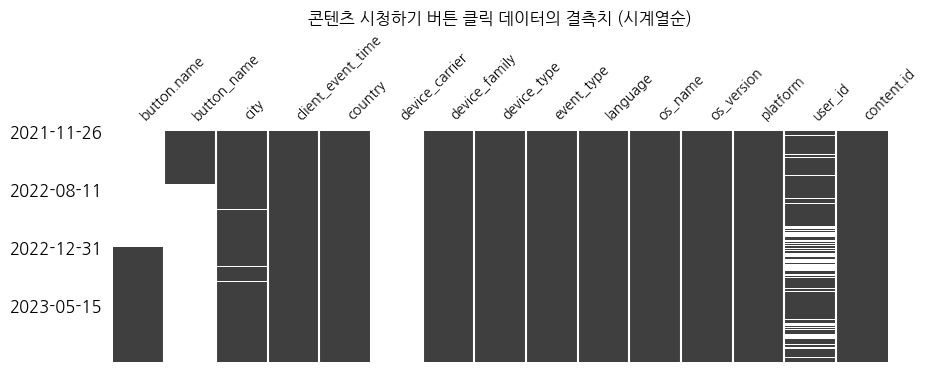

In [194]:
# 1. 시계열 정렬 및 컬럼 순서 변경
# 뒤의 2개 컬럼을 앞으로 가져오고 나머지를 붙입니다.
all_cols = click_content_page_start_content_button_kr.columns
reordered_cols = all_cols[-2:] + all_cols[:-2]

sort_df_pl = click_content_page_start_content_button_kr.sort("client_event_time").select(reordered_cols)
sort_df_pd = sort_df_pl.to_pandas()

# 2. 안전한 인덱스 추출 (데이터 길이에 맞춰 4개 지점 선정)
total_len = len(sort_df_pd)
if total_len > 0:
    # 0, 25%, 50%, 75% 지점의 인덱스를 정수로 계산 (마지막 인덱스는 total_len-1)
    safe_indices = [0, total_len // 4, total_len // 2, int(total_len * 0.75)]
    
    # 해당 인덱스의 날짜 라벨 생성
    date_labels = [sort_df_pd['client_event_time'].iloc[i].date() for i in safe_indices]

    # 3. 시각화
    plt.figure(figsize=(10, 3))
    # msno.matrix 내부에서 yticks를 건드리는 경우가 있어 ax를 명시적으로 받는 것이 안전합니다
    ax = msno.matrix(sort_df_pd, figsize=(10, 3), fontsize=10, sparkline=False)

    # 핵심: set_yticks로 위치를 먼저 고정하고 set_yticklabels로 라벨을 붙입니다
    ax.set_yticks(safe_indices)
    ax.set_yticklabels(date_labels, rotation=0)
    
    plt.title('콘텐츠 시청하기 버튼 클릭 데이터의 결측치 (시계열순)')
    plt.show()
else:
    print("⚠️ 데이터가 비어 있어 시각화를 진행할 수 없습니다.")

button.name의 경우 개편 후       
button_name의 경우 개편 전의 데이터를 나타낸다.    

대략 22년 5월부터 22년 12월까지는 관련 정보가 저장되어 있지 않다 -> 로그 기록이 없었던 듯

In [195]:
click_content_page_start_content_button_kr['button.name'].unique()

button.name
str
"""무료로 들어보기"""
"""할인받고 구독 시작"""
"""콘텐츠 구독하기"""
"""무료로 시작하기"""
"""콘텐츠 이어보기"""
"""구독 시작하기"""
"""최저가로 시작하기"""
null
"""최저가 혜택 받기"""


버튼은 각유저의 활성상태에 따른 이름 차이가 존재한다.

# click.content_page_more_review_button
- 콘텐츠 후기 더보기 버튼 클릭

| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | content.id         | object | 콘텐츠 id                                       | -     |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button_name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 전   |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button.name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 후  |

In [196]:
click_content_page_more_review_button_kr = preprocess_korea_data('click_content_page_more_review_button.parquet')

🚀 [click_content_page_more_review_button.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌──────────────────────┬──────────────┐
│ country              ┆ count_star() │
│ ---                  ┆ ---          │
│ str                  ┆ u32          │
╞══════════════════════╪══════════════╡
│ South Korea          ┆ 93527        │
│ Australia            ┆ 173          │
│ United States        ┆ 77           │
│ United Arab Emirates ┆ 42           │
│ Japan                ┆ 36           │
│ Germany              ┆ 25           │
│                      ┆ 18           │
│ France               ┆ 13           │
│ United Kingdom       ┆ 11           │
│ Vietnam              ┆ 9            │
└──────────────────────┴──────────────┘
=== 전처리 완료: click_content_page_more_review_button.parquet (한국 데이터) ===
총 데이터 수: 93527행
--------------------------------------------------


In [ ]:
click_content_page_more_review_button_kr_summary = profile_dataframe(click_content_page_more_review_button_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (93527, 13)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-12-14 17:38:04 ┆ 2024-01-01 03:44:14 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (13, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬───────────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                                  │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                                   │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                                   │
╞═══════════════════╪════════════╪═════════════╪══════════╪═══════════════════════════════════════╡
│ city              ┆ 148        ┆ 0.16        ┆ 205 

- 유져 아이디가 88% 결측치
    - 로그인 하지 않은 상태일 때 후기를 많이 살펴본다는 의미?
    - Chrome Headless는 크롤러로 볼 수 있다.
    - 후기 수집 크롤러 ㅜㅅㅜ 나빠요

In [198]:
# 1. 'Chrome Headless' 필터링 및 날짜 추출
# client_event_time에서 날짜(date)만 뽑아내어 그룹화합니다.
headless_daily_counts = (
    click_content_page_more_review_button_kr
    .filter(pl.col("os_name") == "Chrome Headless")
    .with_columns(
        pl.col("client_event_time").dt.date().alias("event_date")
    )
    .group_by("event_date")
    .agg(pl.len().alias("count"))
    .sort("event_date")
)

# 2. 결과 출력 (상위 30행 설정 적용 상태)
print("=== [Bot Detection] Chrome Headless 일별 유입 횟수 ===")
print(headless_daily_counts)

# 3. 전체 데이터 대비 비중 확인 (참고용)
total_count = click_content_page_more_review_button_kr.height
headless_total = headless_daily_counts.select(pl.col("count").sum()).item()

print(f"\n전체 클릭 중 Headless 비중: {(headless_total / total_count * 100):.2f}%")

=== [Bot Detection] Chrome Headless 일별 유입 횟수 ===
shape: (3, 2)
┌────────────┬───────┐
│ event_date ┆ count │
│ ---        ┆ ---   │
│ date       ┆ u32   │
╞════════════╪═══════╡
│ 2022-01-21 ┆ 8360  │
│ 2022-01-23 ┆ 22729 │
│ 2022-01-26 ┆ 18353 │
└────────────┴───────┘

전체 클릭 중 Headless 비중: 52.86%


3일동안 크롤러의 데이터가 로그의 50%정도의 비율로 존재

# enter.payment_page

결제 페이지 진입


| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **enter.payment_page**                              | 결제 페이지 진입                        | -                  | -      | -                                                | -        |

In [199]:
enter_payment_page_kr = preprocess_korea_data('enter_payment_page.parquet')

🚀 [enter_payment_page.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬──────────────┐
│ country        ┆ count_star() │
│ ---            ┆ ---          │
│ str            ┆ u32          │
╞════════════════╪══════════════╡
│ South Korea    ┆ 162367       │
│ United States  ┆ 768          │
│ Japan          ┆ 345          │
│ Canada         ┆ 275          │
│                ┆ 162          │
│ Australia      ┆ 152          │
│ Germany        ┆ 109          │
│ Singapore      ┆ 86           │
│ United Kingdom ┆ 85           │
│ Vietnam        ┆ 79           │
└────────────────┴──────────────┘
=== 전처리 완료: enter_payment_page.parquet (한국 데이터) ===
총 데이터 수: 162367행
--------------------------------------------------


In [200]:
enter_payment_page_kr_summary = profile_dataframe(enter_payment_page_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (162367, 12)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-11-03 11:39:46 ┆ 2023-12-10 23:56:01 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (12, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 2376       ┆ 1.46        ┆ 307      ┆ Seoul            

- 관련 로그가 22년 11월 부터 수집 / 다른 대부분 데이터는 21년도부터 있어서 연결해서 살펴보기 어려운 부분이 있음, 데이터들의 공통된 시간대를 살펴보는것 필요할듯
- 결제 완료 데이터와 묶어서 결제 페이지 이탈율을 확인 해볼 수 있음
- 같은 유저가 반복적으로 결제페이지를 들어갔다면 결제 오류 or 결제 갈등(?) or 개발자..

In [202]:
enter_payment_page_kr['user_id'].value_counts(sort=True).head(10)

user_id,count
str,u32
null,6107
"""233094e3798cb9f681d9d1466e276ed8""",101
"""fe3beafec5633844a56822e010bf73f9""",55
"""d3b2f51ede04364bd9861f8d261f26ec""",55
"""23380fbcdeecb36c1ad92a7558315b63""",49
"""29126bff58f932e3b36adef464f8fdbb""",49
"""06536039eaf41ade42390ee91f5f2f5b""",49
"""f548551d5913830113ffc2a54b825d7c""",48
"""9c6c76f6891386bf0c2ca43e9ab663e9""",46


In [203]:
# max 유저
# 일단위로 결제페이지를 들락날락 -> QA인듯
target_user_id = '233094e3798cb9f681d9d1466e276ed8'

result = (
    enter_payment_page_kr
    .filter(pl.col("user_id") == target_user_id)
    .sort("client_event_time")
    .head(30)
)

print(result)

shape: (30, 12)
┌────────┬────────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ city   ┆ client ┆ countr ┆ devic ┆ devic ┆ devic ┆ event ┆ langu ┆ os_na ┆ os_ve ┆ platf ┆ user_ │
│ ---    ┆ _event ┆ y      ┆ e_car ┆ e_fam ┆ e_typ ┆ _type ┆ age   ┆ me    ┆ rsion ┆ orm   ┆ id    │
│ str    ┆ _time  ┆ ---    ┆ rier  ┆ ily   ┆ e     ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│        ┆ ---    ┆ str    ┆ ---   ┆ ---   ┆ ---   ┆ str   ┆ str   ┆ str   ┆ str   ┆ str   ┆ str   │
│        ┆ dateti ┆        ┆ str   ┆ str   ┆ str   ┆       ┆       ┆       ┆       ┆       ┆       │
│        ┆ me[μs] ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
╞════════╪════════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ Asan   ┆ 2022-1 ┆ South  ┆ null  ┆ Windo ┆ Windo ┆ enter ┆ Korea ┆ Chrom ┆ 108.0 ┆ Web   ┆ 23309 │
│        ┆ 2-10   ┆ Korea  ┆       ┆ ws    ┆ ws    ┆ .paym ┆ n     ┆ e     

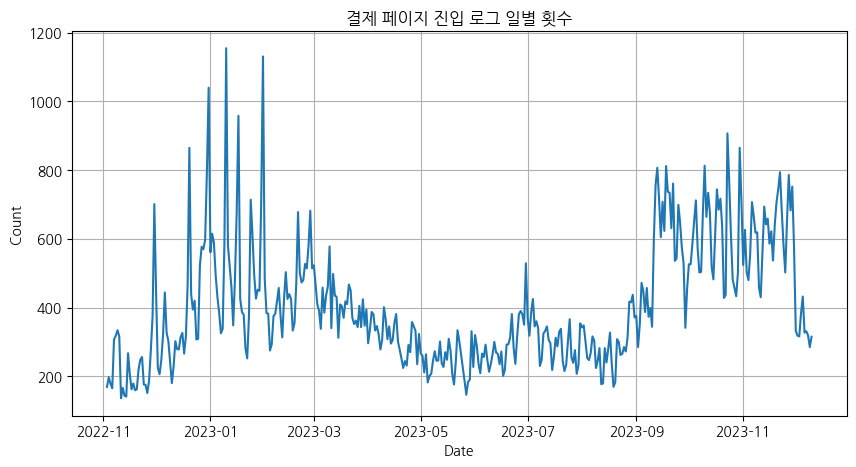

In [207]:
daily_counts = (
    enter_payment_page_kr
    .group_by(
        # 연산 결과에 별칭(alias)을 주어 컬럼명을 유지시킵니다.
        pl.col("client_event_time").dt.truncate("1d")
    )
    .agg(
        pl.len().alias("count")
    )
    .sort("client_event_time") # 이제 이 이름으로 정렬이 가능합니다.
)

# 시각화 부분은 동일
pd_daily_counts = daily_counts.to_pandas()

plt.figure(figsize=(10, 5))
plt.plot(pd_daily_counts['client_event_time'], pd_daily_counts['count'], linestyle='-')
plt.title('결제 페이지 진입 로그 일별 횟수')
plt.xlabel('Date')
plt.ylabel('Count')
plt.grid(True)
plt.show()

23년 2,3분기에 상대적으로 떨어짐 / 다른기간이 프로모션등이 있었는지 확인필요

# complete.subscription
- 첫 결제 완료
- 요금제 종류, 쿠폰 종류, 쿠폰 혜택 종류, 정상가, 할인가, 할인액, 결제수단 타입
- 첫 결제가 중복인 경우는 첫 결제 환불 후 다시 결제한 케이스로 간주


| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **complete.subscription**                         | 첫 결제 완료             | plan.price            | int64 | 정상가                                          | -|
| **complete.subscription**                         | 첫 결제 완료             | paid_amount           | int64 | 실제 결제 금액                                  | -|
| **complete.subscription**                         | 첫 결제 완료             | coupon.discount_amount | int64| 할인액                                          | 정상가 - 실제 결제 금액|
| **complete.subscription**                         | 첫 결제 완료             | pg.type               | object| 결제수단 타입                                   | A, B, C는 각기 다른 간편결제 수단|

In [208]:
complete_subscription_kr = preprocess_korea_data('complete_subscription.parquet')

🚀 [complete_subscription.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬──────────────┐
│ country        ┆ count_star() │
│ ---            ┆ ---          │
│ str            ┆ u32          │
╞════════════════╪══════════════╡
│ South Korea    ┆ 13651        │
│                ┆ 383          │
│ United States  ┆ 69           │
│ Japan          ┆ 35           │
│ Canada         ┆ 20           │
│ Vietnam        ┆ 16           │
│ Australia      ┆ 16           │
│ United Kingdom ┆ 13           │
│ Netherlands    ┆ 11           │
│ Malaysia       ┆ 9            │
└────────────────┴──────────────┘
=== 전처리 완료: complete_subscription.parquet (한국 데이터) ===
총 데이터 수: 13651행
--------------------------------------------------


In [209]:
complete_subscription_kr_summary = profile_dataframe(complete_subscription_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (13651, 16)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-01-01 15:17:25 ┆ 2024-01-01 01:18:11 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (16, 5)
┌────────────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column                 ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---                    ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str                    ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞════════════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city                   ┆ 140        ┆ 1.03        ┆

- 22년 1월부터 23년 12월말까지 첫결제 데이터

In [211]:
mismatch_df = complete_subscription_kr.filter(
    (pl.col("plan.price") - pl.col("paid_amount")) != pl.col("coupon.discount_amount")
)

# 2. 행 개수 확인 (두 가지 방법 중 편한 것을 사용하세요)
mismatch_count = len(mismatch_df)  # 방법 1
# mismatch_count = mismatch_df.height  # 방법 2

print(f"결제 금액 불일치 건수: {mismatch_count}")

# 3. 만약 불일치 건수가 있다면 샘플 확인
if mismatch_count > 0:
    print(mismatch_df.select([
        "user_id", "plan.price", "paid_amount", "coupon.discount_amount"
    ]).head(5))

결제 금액 불일치 건수: 0


할인금액과 실제 결제 금액간의 차이가 존재하는 행은 없다

첫 결제가 중복인 경우는 첫 결제 환불 후 다시 결제한 케이스 확인해보기

In [212]:
multi_pay = (
    complete_subscription_kr
    .group_by("user_id")
    .agg(
        pl.len().alias("첫 결제 완료 횟수")
    )
    .filter(pl.col("첫 결제 완료 횟수") != 1) # 1회가 아닌(즉, 2회 이상) 유저만 필터링
    .sort("첫 결제 완료 횟수", descending=True) # 많이 결제한 순으로 정렬 (옵션)
)

print(multi_pay)

shape: (350, 2)
┌──────────────────────────────────┬───────────────────┐
│ user_id                          ┆ 첫 결제 완료 횟수 │
│ ---                              ┆ ---               │
│ str                              ┆ u32               │
╞══════════════════════════════════╪═══════════════════╡
│ 3767d4c7a827422fccf61d45ae889669 ┆ 8                 │
│ f833cca4c382ac8c502c6f99bc432725 ┆ 6                 │
│ ccea16701cf72a9027d7d5f2c3d3019c ┆ 5                 │
│ e04c24e899b1e875ed432a7b398a4308 ┆ 4                 │
│ 24102bc5428dc2911d2dae4682e907f7 ┆ 3                 │
│ 51c5812ce7495e9037884922214ce2a8 ┆ 3                 │
│ f614cfe2171a6573b3c2af7db33f390c ┆ 3                 │
│ 3b4f4a292895752991395bf3984ffe09 ┆ 3                 │
│ 675e7499240a1081a94442d8ab71f7a5 ┆ 3                 │
│ 34485ce03385ca325be16d5042baad8f ┆ 3                 │
│ 7c2941bbc31397b5f020e9522cfa5fc8 ┆ 3                 │
│ 5319cec4d1e6adc224bc0c623545ac1d ┆ 3                 │
│ 508023b34654ca6b261b

In [213]:
# 1. 재결제 유저 데이터 (multi_pay)
multi_pay = (
    complete_subscription_kr
    .group_by("user_id")
    .agg(pl.len().alias("pay_count"))
    .filter(pl.col("pay_count") > 1)
)

# 2. 통계치 계산
total_unique_users = complete_subscription_kr["user_id"].n_unique() # 전체 결제 유저 수
multi_pay_user_count = len(multi_pay)         # 2회 이상 결제 유저 수

# 3. 비율 계산 (Pandas 스타일 문장 재현)
ratio = (multi_pay_user_count / total_unique_users) * 100

print(f"전체 결제 유저 수: {total_unique_users}")
print(f"2회 이상 결제 발생 유저 수: {multi_pay_user_count}")
print(f"중복/재결제 유저 비율은 {round(ratio, 2)}% 입니다.")

전체 결제 유저 수: 13254
2회 이상 결제 발생 유저 수: 350
중복/재결제 유저 비율은 2.64% 입니다.


In [217]:
# 3767d4c7a827422fccf61d45ae889669 유저의 첫결제 완료 시점 살펴보기
target_user = 'ccea16701cf72a9027d7d5f2c3d3019c'

# 특정 유저의 결제 시간만 추출하여 정렬
user_payment_timeline = (
    complete_subscription_kr
    .filter(pl.col("user_id") == target_user)
    .select("client_event_time")
    .sort("client_event_time")
)

print(user_payment_timeline)

shape: (5, 1)
┌─────────────────────┐
│ client_event_time   │
│ ---                 │
│ datetime[μs]        │
╞═════════════════════╡
│ 2023-10-20 16:01:33 │
│ 2023-10-23 14:26:22 │
│ 2023-10-26 10:12:19 │
│ 2023-11-13 16:44:59 │
│ 2023-11-23 12:04:28 │
└─────────────────────┘


첫결제를 다수 진행한 유저는 첫 결제 시점이 넓은 기간에 걸쳐 존재한다.    
이러한 경우 구매 리텐션을 확인하는데 첫 구매시점을 어떤 시점으로 봐야하는지 어려움이 있을 수 있다.     
이런 유저를 제외하고 살펴볼지 포함하고 살펴볼지는 추가적인 분석작업을 통해 진행 해보길

In [219]:
# 유저별로 이전 결제와의 시간 차이(diff) 계산
pay_diff_analysis = (
    complete_subscription_kr
    .sort(["user_id", "client_event_time"])
    .with_columns([
        pl.col("client_event_time")
        .diff()
        .over("user_id")
        .alias("time_delta")
    ])
    .filter(pl.col("time_delta").is_not_null()) # 첫 번째 결제는 diff가 null이므로 제외
)

# 시간 차이를 '시간(hours)' 단위로 변환하여 통계 확인
print(
    pay_diff_analysis
    .select([
        (pl.col("time_delta").dt.total_seconds() / 3600).alias("diff_hours")
    ])
    .describe()
)

shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ diff_hours   │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 397.0        │
│ null_count ┆ 0.0          │
│ mean       ┆ 583.307671   │
│ std        ┆ 1700.943735  │
│ min        ┆ 0.0          │
│ 25%        ┆ 0.203611     │
│ 50%        ┆ 15.719444    │
│ 75%        ┆ 314.350556   │
│ max        ┆ 15998.009722 │
└────────────┴──────────────┘


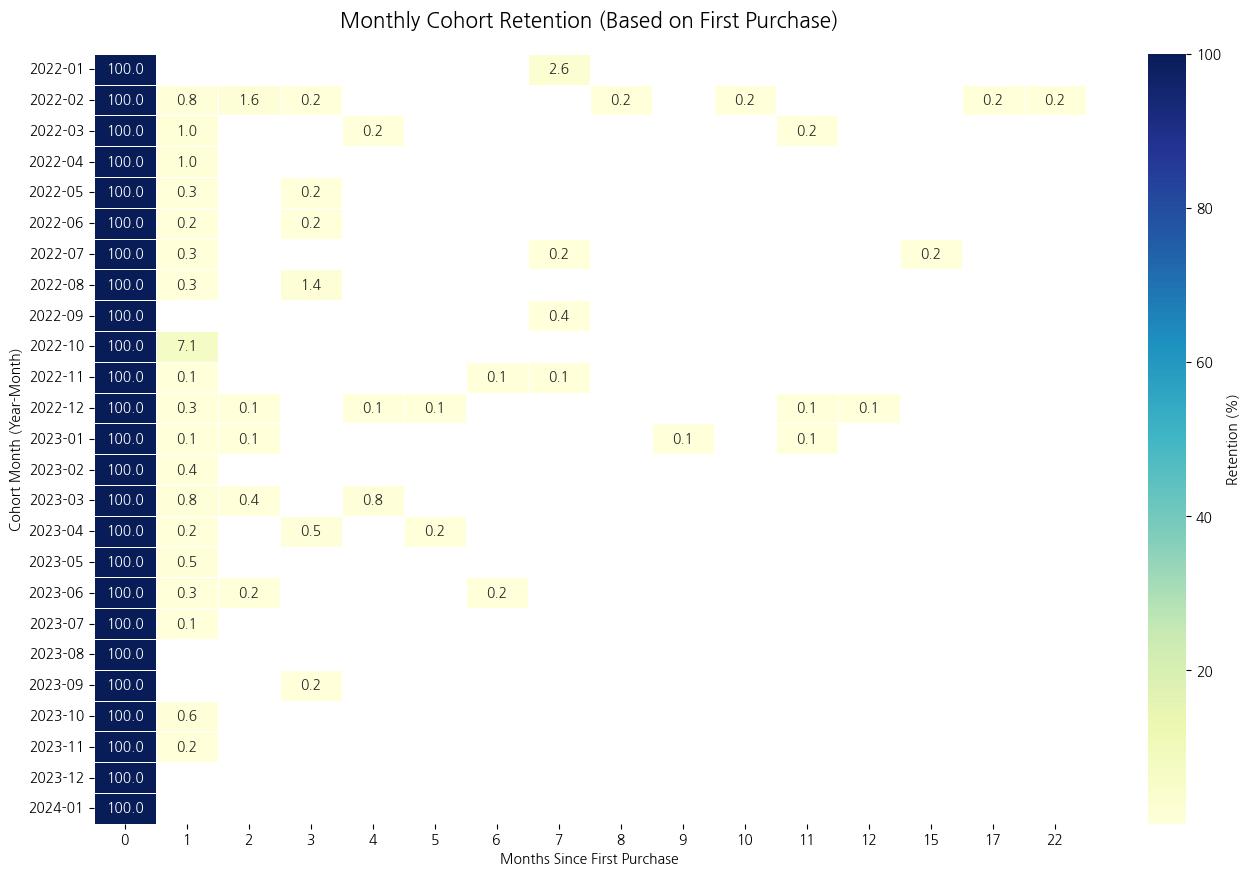

In [222]:
# 1. 코호트 계산 및 날짜 포맷팅 (문자열 변환으로 가독성 확보)
cs_cohort = complete_subscription_kr.with_columns([
    pl.col("client_event_time").min().over("user_id").dt.truncate("1mo").dt.to_string("%Y-%m").alias("cohort_month"),
    pl.col("client_event_time").dt.truncate("1mo").alias("order_month"),
    pl.col("client_event_time").min().over("user_id").dt.truncate("1mo").alias("cohort_month_raw")
])

# 2. 리텐션 데이터 집계
cohort_data = (
    cs_cohort
    .group_by(["cohort_month", "order_month", "cohort_month_raw"])
    .agg(pl.col("user_id").n_unique().alias("user_count"))
    .with_columns([
        ((pl.col("order_month").dt.year() - pl.col("cohort_month_raw").dt.year()) * 12 +
         (pl.col("order_month").dt.month() - pl.col("cohort_month_raw").dt.month())).alias("cohort_period")
    ])
    .sort(["cohort_month_raw", "cohort_period"])
)

# 3. 피벗 및 비율 계산
cohort_pivot = (
    cohort_data.to_pandas()
    .pivot(index="cohort_month", columns="cohort_period", values="user_count")
)
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

# 4. 시각화 (날짜가 깔끔해진 버전)
plt.figure(figsize=(16, 10))
sns.heatmap(retention, annot=True, fmt=".1f", cmap="YlGnBu", 
            cbar_kws={'label': 'Retention (%)'}, linewidths=.5)
plt.title("Monthly Cohort Retention (Based on First Purchase)", fontsize=15, pad=20)
plt.ylabel("Cohort Month (Year-Month)")
plt.xlabel("Months Since First Purchase")
plt.show()

In [223]:
# 1. 유저별 첫 결제 정보 생성 (모수 확인용)
first_purchase_df = (
    complete_subscription_kr
    .group_by("user_id")
    .agg([
        pl.col("client_event_time").min().alias("first_time"),
        pl.col("device_family").first().alias("device"), # 첫 유입 기기
        pl.col("os_name").first().alias("os")            # 첫 유입 OS
    ])
    .with_columns(
        pl.col("first_time").dt.truncate("1mo").dt.to_string("%Y-%m").alias("cohort_month")
    )
)

# 2. 월별 신규 결제 유저 수(모수) 집계
cohort_size_check = (
    first_purchase_df
    .group_by("cohort_month")
    .agg(pl.len().alias("new_user_count"))
    .sort("cohort_month")
)

# 3. 2022-10 코호트 유저들의 상세 특성 (기기/OS 비중)
oct_22_users = (
    first_purchase_df
    .filter(pl.col("cohort_month") == "2022-10")
    .group_by(["device", "os"])
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)

print("--- [월별 신규 결제 유저 모수 확인] ---")
print(cohort_size_check)

print("\n--- [2022-10 코호트 유저 유입 특성] ---")
print(oct_22_users)

--- [월별 신규 결제 유저 모수 확인] ---
shape: (25, 2)
┌──────────────┬────────────────┐
│ cohort_month ┆ new_user_count │
│ ---          ┆ ---            │
│ str          ┆ u32            │
╞══════════════╪════════════════╡
│ 2022-01      ┆ 39             │
│ 2022-02      ┆ 505            │
│ 2022-03      ┆ 615            │
│ 2022-04      ┆ 509            │
│ 2022-05      ┆ 598            │
│ 2022-06      ┆ 562            │
│ 2022-07      ┆ 660            │
│ 2022-08      ┆ 369            │
│ 2022-09      ┆ 245            │
│ 2022-10      ┆ 184            │
│ 2022-11      ┆ 892            │
│ 2022-12      ┆ 1167           │
│ 2023-01      ┆ 1406           │
│ 2023-02      ┆ 248            │
│ 2023-03      ┆ 260            │
│ 2023-04      ┆ 428            │
│ 2023-05      ┆ 373            │
│ 2023-06      ┆ 639            │
│ 2023-07      ┆ 782            │
│ 2023-08      ┆ 507            │
│ 2023-09      ┆ 562            │
│ 2023-10      ┆ 352            │
│ 2023-11      ┆ 555            │
│ 202

# renew.subscription.csv

- 정기 결제 완료

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **renew.subscription**                            | 정기 결제 완료           | plan.price            | int64 | 정상가                                          | -|
| **renew.subscription**                            | 정기 결제 완료           | paid_amount           | int64 | 실제 결제 금액                                  | -|
| **renew.subscription**                            | 정기 결제 완료           | coupon.discount_amount | int64| 할인액                                          | 정상가 - 실제 결제 금액|                              
| **renew.subscription**                            | 정기 결제 완료           | pg.type               | object| 결제수단 타입                                   | A, B, C는 각기 다른 간편결제 수단|

In [ ]:
rs = load_preprocessing('renew_subscription.csv')

- pg.type은 결측치가 많아서 활용에 어려움이 있어보임
- 모든 정기 결제 고객은 첫구매 데이터가 존재하는지 확인필요
- 기간은 22년 9월부터 23년 12월말까지

In [ ]:
print(f'재구매 리스트에는 있는데 첫 구매 리스트에는 없는 유저 숫자는 {len(set(rs.user_id.unique()) - set(cs.user_id.unique()))}명이다. 이는 재구매 인원의 {round(len(set(rs.user_id.unique()) - set(cs.user_id.unique())) / rs.user_id.nunique()* 100,2)} %이다.' )

첫구매가 존재하는 재구매 인원만 필터하여 재구매 하는 유저의 특성을 그렇지 않은 유저들과 비교해서 살펴보면 좋을 듯
- 어떤 유저 특성을 가지는지
- 어떤 컨텐츠를 많이 소비 했는지
- 액티브 정도는 얼마나 되는지

# resubscribe.subscription
만료 후 재구독 완료

In [ ]:
rss = load_preprocessing('resubscribe_subscription.csv')

- 구독 시작이 7498명인데, 재구독이 761명 뿐이다.
- 12개월 구독권도 있기에 아직 결제 시점이 도달하지 않은 유저가 존재할 수 있음

In [ ]:
print(f'재구독은 했지만 첫구독은 정보가 없는 유저는 {len(set(rss.user_id) - set(rs.user_id))}명이다.\n해당유저들이 free_trial로 시작했는지 확인 필요')

[링크 텍스트](https://)# start.free_trial
- 서비스 무료체험 시작

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **start.free_trial**                              | 서비스 무료체험 시작      | plan.price            | int64 | 정상가                                          | -|
| **start.free_trial**                              | 서비스 무료체험 시작      | plan.type             | object| 요금제 종류                                    | -|
| **start.free_trial**                              | 서비스 무료체험 시작      | trial.type           | object| 무료체험 방식                                   | "- type A(구버전): 특정 컨텐츠 하나 영구 무료체험<br>- type B(신버전): 기간 단위로 전체 컨텐츠 경험(중복X)"|


In [ ]:
sf = load_preprocessing('start_free_trial.csv')

- 무료 체험 이후에 정기 구독을 시작하는 경우는 있는가? 있다면 그 비율은?
- 정기 구독이후에 무료체험을 하는 유저는 있는가? (데이터 오류로 보임 체크 필요)
- 무료 체험을 하는 유저는 어떤 컨텐츠를 많이 소비하는가?

In [ ]:
pd.crosstab(sf['plan.price'],sf['plan.type'])

유저의 행동별 데이터 확인 필요    
1. 무료이용 -> 첫구독 -> 재구독
2. 무료이용 -> 재구독
3. 첫구독 -> 재구독
4. 첫구독

각 항목별 예외 케이스 데이터가 분명 존재할 듯 잘 나눠서 확인 필요

# start.content
- 콘텐츠 수강 시작

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **start.content**                                 | 콘텐츠 수강 시작         | content.id            | object| 콘텐츠 id                                       | -|
| **start.content**                                 | 콘텐츠 수강 시작         | content.difficulty    | int64 | 콘텐츠 난이도                                   | -|

In [ ]:
sc = load_preprocessing('start_content.csv')

- 유저 유니크 숫자는 4.2만이다
- 유저별 content.id는 시작하는 경우가 유일할 것으로 생각되는데 실제 그런지 확인 필요

In [ ]:
result = sc[['content.difficulty','user_id']].drop_duplicates()['content.difficulty'].value_counts().to_frame()
result.index.name ='난이도에 따른 시작유저 숫자'
result

In [ ]:
sc[['user_id','content.id']].drop_duplicates()['user_id'].value_counts().head(10) # 유저의 컨텐츠 시작횟수

In [ ]:
sc[['user_id','content.id']].value_counts() # 한 유저가 동일한 컨텐츠를 여러번 시청한 경우가 있다.

In [ ]:
# 위 케이스1
sc[(sc.user_id =='23d69a936e8267e6f2ec7037bd3b54ca') & (sc['content.id'] == '4641438a6c81ef572d997dbdc9100f8b')]

1초 내에 여러번 응답이 된 것으로 보인다. 로그 이슈로 보임

In [ ]:
# 위 케이스2
# 일본..? 뭐고.. 12월 24일에 여러회차 시도했던것으로 보임
sc[(sc.user_id =='5c2ce4062550e53fa30c3f53b8c9b181') & (sc['content.id'] == '61b6463287573f00de13a930805a52d6')]

In [ ]:
# 위 케이스3
# 일본..? 뭐고.. 12월 24일에 여러회차 시도했던것으로 보임
sc[(sc.user_id =='40651151784699b184c58ddcd2dedf9d') & (sc['content.id'] == 'c269eb6df3a374b464f7c18f12fa398f')]

1초 내에 여러번 응답이 된 것으로 보인다. 로그 이슈로 보임
- 대체로 로그 이슈일 것이다. 중복 제거하면 유니크 케이스에 대해 확인 가능

추가질문
- 각 유저는 어떤 정기권을 통해 어떤 컨텐츠로 유입이 되었는가?
- 인기 많은 처음 시작 컨텐츠는 무엇인가
- 컨텐츠 난이도에 따른 컨텐츠 시작 양상 특징은?
- 여러 컨텐츠를 들은 유저들은 수강 패턴이 존재하는지?

# enter.lesson_page
- 콘텐츠는 여러개의 레슨로 구성되어있습니다.

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **enter.lesson_page**                             | 레슨 시작                | content.id            | object| 콘텐츠 id                                       | -|
| **enter.lesson_page**                             | 레슨 시작                | lesson.id             | object| 레슨 id                                         | -|
| **enter.lesson_page**                             | 레슨 시작                | is_free_trial         | boolean| 무료 공개 레슨 진입 여부                        | 특정 기준 시점으로 사용 안 함|
| **enter.lesson_page**                             | 레슨 시작                | is_trial              | boolean| “무료 공개 레슨 + 미구독 유저”인지 여부         | -|

In [ ]:
el = load_preprocessing('enter_lesson_page.csv')

- 행이 2천만개 있다.
- user_id가 없는 데이터가 7%... / 회원 가입을 하지 않은 유저인 것인지 로그 누락인지는 별도 확인필요
- 181개의 content와 5479개의 lesson가 존재
    - 하나의 레슨은 하나의 컨텐츠에만 종속되는지 확인 필요


In [ ]:
el[['user_id','content.id','lesson.id']].dropna().value_counts().head(20)

하나의 유저가 한개의 컨텐츠의 하나의 레슨을 8318번 시작했다? 하루에 20번씩해도 2년이다. 뭐고 이거

In [ ]:
# 최상위 데이터의 샘플 필터
el[(el.user_id =='4f74b6e2f650f4c8db87579e44f5b7d6') & (el['content.id'] =='595cb4bbfc83e683b0314ca1312cfbde') & (el['lesson.id'] =='bef2ec4ced488c2bd28cbba9752f73c2')].sort_values('client_event_time').head(10)\
        [['city','client_event_time','user_id','lesson.id']]

해당 유저는 다양한 레슨에 대해서 다양하게 시도를 했다. 용인시에 사는 서비스 개발자로 추정 (디버깅 or QA 과정의 데이터가 섞인 것으로 보임 해당 데이터들 필터 해줘야함)

In [ ]:
counts =el[el.user_id =='4f74b6e2f650f4c8db87579e44f5b7d6'].shape[0]
print(f'이상치 유저 한명이 발생시킨 시작로그 개수는 {counts}개이다. 이런 데이터는 걸러줘야한다')

In [ ]:
# 두번째로 로그 많은 유저
el[el.user_id =='1400ef9237d90f6e326678e7758e76ce']['lesson.id'].value_counts()

# complete.lesson
- 레슨 완료	콘텐츠

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **complete.lesson**                               | 레슨 완료                | content.id            | object| 콘텐츠 id                                       | -|
| **complete.lesson**                               | 레슨 완료                | lesson.id             | object| 레슨 id                                         | -|

In [ ]:
cl = load_preprocessing('complete_lesson.csv')

- 레슨 완료 데이터는 540만행
- 레슨 유니크 값은 5050개다. 레슨 시작 데이터에서 레슨 유니크 값은 5479개이다.
    - 10%정도의 데이터는 레슨 완료 케이스가 하나도 없다? -> 실제 그런것인지 확인필요
        - 레슨 완료 케이스가 없는 레슨 수강하는 동안 다른 레슨을 완료한 유저가 존재한다면 주장이 옳다고 볼 수 있다.

# click.lesson_page_related_question_box
- 레슨 페이지 내 질문 목록 클릭

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **click.lesson_page_related_question_box**        | 레슨 페이지 내 질문목록 클릭 | content.id        | object| 콘텐츠 id                                       | -|
| **click.lesson_page_related_question_box**        | 레슨 페이지 내 질문목록 클릭 | lesson.id         | object| 레슨 id                                         | -|
| **click.lesson_page_related_question_box**        | 레슨 페이지 내 질문목록 클릭 | question.id       | object| 질문 id                                         | -|

In [ ]:
clpr = load_preprocessing('click_lesson_page_related_question_box.csv')

- 질문 목록 클릭의 활성화 정도?
- 레슨 완료율과의 연관성이 존재?

# end.content
- 콘텐츠 수강 완료
- 모든 레슨를 시청하면 해당 테이블에 로그가 쌓임

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **end.content**                                   | 수강 완료                | content.id            |       | 콘텐츠 id                                       | -|

In [ ]:
ec = load_preprocessing('end_content.csv')

- 시작한 컨텐츠 id가 151개인데, 종료된 컨텐츠 id가 160개 이다. ㅎㅎ ;;
- 컨텐츠와 레슨의 완료의 정확한 기준(로그가 발생하는 트리거)을 알아야 추가 분석이 가능할 거 같다. 현실적으로 확인이 어렵기에 추정을 통해 진행하자
- start와 비교해서 이탈하는 유저는 어느 정도 될지?
- 중도 이탈 유저의 특징

# click.cancel_plan_button
- 구독 취소 버튼 클릭
- 구독 취소 버튼을 클릭했다면 구독 취소가 이루어진 것으로 간주

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **click.cancel_plan_button**                      | 구독 취소 버튼 클릭       | -                     | -     | -                                              | -|

In [ ]:
ccp = load_preprocessing('click_cancel_plan_button.csv')

- 14643명이 구독을 취소했다.14643명이나 구독을 했었나..?
- 첫구독 7498 / 재구독 761 / 무료시작 16309
- 무료시작한 유저도 구독 정지를 한 케이스가 있나보다.
- 구독종료를 한 이후에 다시 구독을 시작 한 경우도 있는지 체크해보자

## DATA2 참고
- 전체 데이터에 포함된 user_id unique 파악
- 전체 데이터의 공통된 기간 영역
- 존재하는 기간이 다른 데이터 간에 해석 가능한 방법이 있을지 체크
- 개발, QA로 보이는 user_id들에 대해 판단하고 제거해주는 과정 필요
- 웹 크롤러로 보이는 (chrome headless) 로그들을 제거할 필요 있음
- 해외 이용의 비중이 적다면 확실히 제거하고 국내, 해외를 최상단에서 구분해서 분석하면 좋을듯!